# <b>[공모전] RNN 시계열 판매량 예측
* 실전 데이터

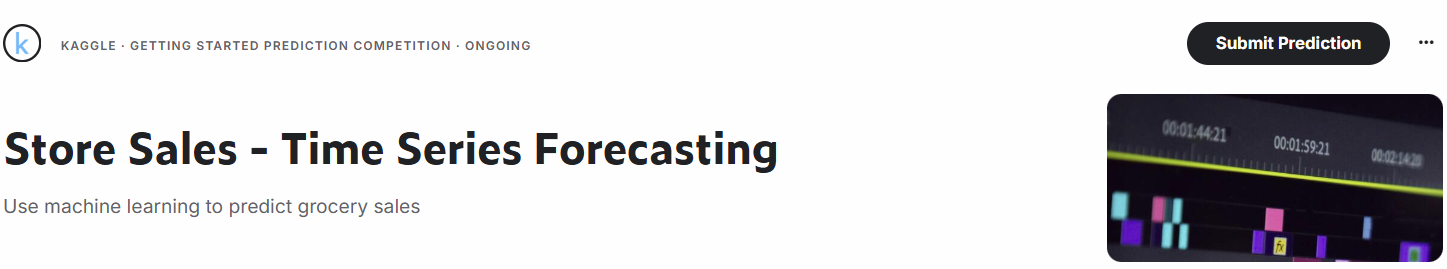
* https://www.kaggle.com/competitions/store-sales-time-series-forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, GRU, Bidirectional
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras.initializers import GlorotNormal    #Xavier

import math
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler


#----------------------------------------------------------------------------------  랜덤시드 고정 
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>평가 매트릭스

$ RMSLE = \sqrt{ \frac{1}{n} \sum_{i=1}^n \left(\log (1 + \hat{y}_i) - \log (1 + y_i)\right)^2} $ 
<pre>
<b>MSE : 모델학습 및 최적화 </b>
<b>RMSE : 모델평가 및 보고 </b>
    
<b>(R)MSE : 단순 수치 차이 </b>
<b>(R)MSLogE : 비율(증강률)이 중요 </b>

증감율에 대한 오차를 계산하고 싶은 경우
작은 수치의 오차에 민감하게 반응해야 하는 경우
성장률/비율이 중요한 경우 - 매출/재고 증강률, 환율, 금리(이자율)
음수값 계산 불가

 y     pred    mse        
100    110     10    ---   10%
1000  1010     10    ---    1%

| 지표 | 수식 (Formula) | 특징 및 용도 | 비고 |
| :--- | :---: | :--- | :--- |
| **MSE** | $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$ | 오차를 제곱하여 계산. 큰 오차에 매우 민감함. | 학습용 **Loss**로 주로 사용 |
| **RMSE** | $\sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}$ | MSE에 루트를 씌움. 실제 데이터와 단위가 일치함. | 일반적인 성능 **Metric** |
| **RMSLE** | $\sqrt{\frac{1}{n} \sum (\log(y_i+1) - \log(\hat{y}_i+1))^2}$ | 로그를 씌워 계산. 상대적 비율 오차를 측정함. | 아웃라이어가 많을 때 유리 |

# <b>Data Load

In [2]:
train = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\train.csv")
test = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\test.csv")
holiday = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\holidays_events.csv", parse_dates=['date'])
oil = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\oil.csv")
submit = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\sample_submission.csv")
store = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\stores.csv")
trans = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\transactions.csv")

dataset = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\train_merge20.csv", parse_dates=['date'])
# 공모전에선 이렇게 dataset처럼 데이터 잘라서 쓰면 안됌

In [3]:
len(submit), len(test), len(train), len(dataset), len(submit)/3

(28512, 28512, 3000888, 1111440, 9504.0)

In [4]:
dataset.head(2)

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN


# <b>EDA

<pre>
train : (1111440 - 9000)  --->  train(80%), val(20%)
test : 9000

In [5]:
test = dataset[-9000:]
len(dataset), len(test)

(1111440, 9000)

In [6]:
train, val  = train_test_split(dataset[ :-9000], test_size=0.2, shuffle=False)
len(train), len(val)

(881952, 220488)

* 데이터 균형확인

In [7]:
#train['store_nbr'].value_counts().plot(kind='bar')
#val['store_nbr'].value_counts().plot(kind='bar')
#test['store_nbr'].value_counts().plot(kind='bar')

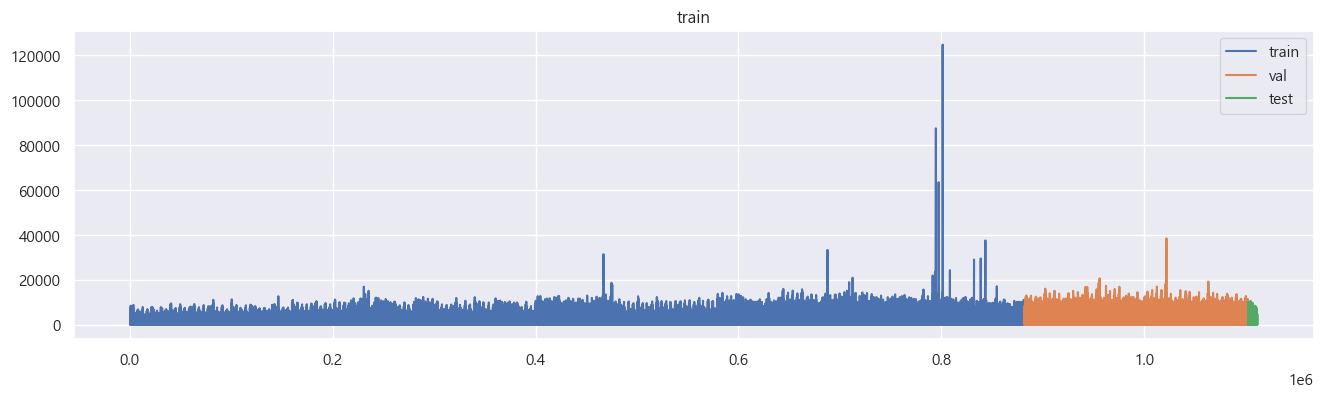

In [8]:
dataset['sales'][ : len(train)].plot(figsize=(16,4),legend=True)
dataset['sales'][len(train) : len(train)+len(val) ].plot(figsize=(16,4),legend=True)
dataset['sales'][ len(train)+len(val) :].plot(figsize=(16,4),legend=True)
plt.legend(['train','val', 'test']) # 범례설정
plt.title('train')
plt.show()

0.8에서 많이 튐 -> 이상치 확인 필요
블프아님

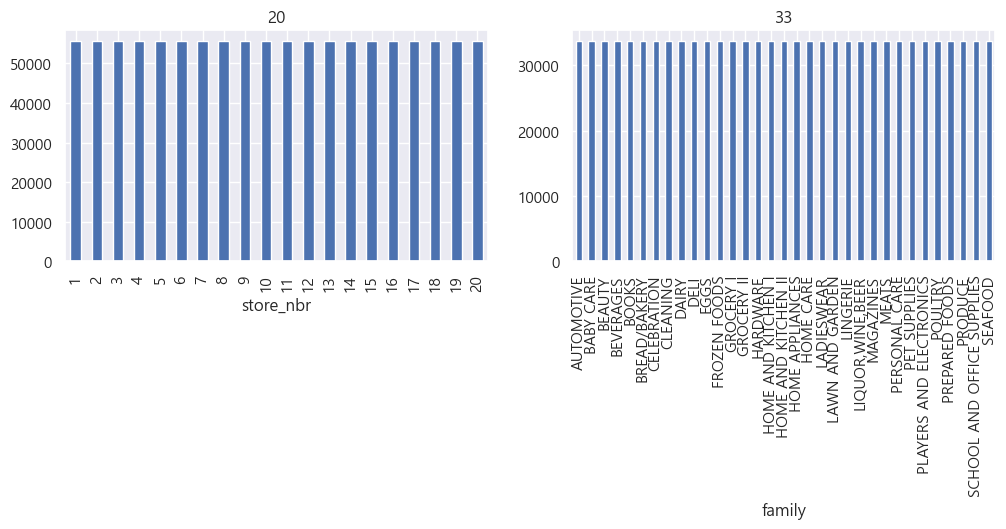

In [9]:
plt.figure(figsize=(12,3))

plt.subplot(1,2,1)
dataset["store_nbr"].value_counts().plot(kind="bar")
plt.title(len(dataset["store_nbr"].value_counts()))

plt.subplot(1,2,2)
dataset["family"].value_counts().plot(kind="bar")
plt.title(len(dataset["family"].value_counts()))

plt.show()

In [10]:
#group_col = ["store_nbr","family"]

# <b>전처리 & 가공

* dataset에 있는 날짜가 holiday에 있는 날짜면 1
* 상위top 파생피쳐 20개
* transactions : 결측
* id : drop
* family, city, state, type : object
* seasonal 패턴 : sin, cos 사이클

In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1111440 entries, 0 to 1111439
Data columns (total 11 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   id            1111440 non-null  int64         
 1   date          1111440 non-null  datetime64[ns]
 2   store_nbr     1111440 non-null  int64         
 3   family        1111440 non-null  object        
 4   sales         1111440 non-null  float64       
 5   onpromotion   1111440 non-null  int64         
 6   city          1111440 non-null  object        
 7   state         1111440 non-null  object        
 8   type          1111440 non-null  object        
 9   cluster       1111440 non-null  int64         
 10  transactions  1073952 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 93.3+ MB


## <b>dataset에 있는 날짜가 holiday에 있는 날짜면 1

In [12]:
# holiday[ holiday['date'].isin( test['date'].unique()  ) ]

In [13]:
dataset['holiday'] = dataset['date'].isin(holiday['date'].unique()).astype(int)
dataset['holiday'] = dataset['holiday'].fillna(0).astype(int)

test['holiday'] = test['date'].isin(holiday['date'].unique()).astype(int)
test['holiday'] = test['holiday'].fillna(0).astype(int)

dataset.head(3)

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,1
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,1
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,1


In [14]:
dataset['holiday'].value_counts()

holiday
0    945120
1    166320
Name: count, dtype: int64

In [15]:
test['holiday'].value_counts()

holiday
0    6360
1    2640
Name: count, dtype: int64

## <b>파생피쳐
* 상위top 파생피쳐 20개

* <b>원리이해 - 파이썬 기본 자료구조

<pre>
<font color=red size=3><b>
리스트        : [1 , 2 , 3]
np.array(..)  : [1   2  3 ]
튜플          : (1  ,2  ,3)
셋            : {1  ,2  ,3}   --- 중복제거(duplicate, cascade)
딕셔너리      : {"a":1, "b":[1,2]}

In [16]:
mylist = [1,2,3,4,4,4,5]
set(mylist)

{1, 2, 3, 4, 5}

In [17]:
sample = pd.DataFrame( {"ss" : [10,20,30,40,50,60,70] })

In [18]:
sample["diff1"] = sample['ss'].diff(1)
sample["shift+1"] = sample['ss'].shift(1)
sample["shift-1"] = sample['ss'].shift(-1)
sample["ma3"] = sample['ss'].rolling(3).mean()

sample

,ss,diff1,shift+1,shift-1,ma3
0,10,NaN,NaN,20.0,NaN
1,20,10.0,10.0,30.0,NaN
2,30,10.0,20.0,40.0,20.0
3,40,10.0,30.0,50.0,30.0
4,50,10.0,40.0,60.0,40.0
5,60,10.0,50.0,70.0,50.0
6,70,10.0,60.0,NaN,60.0


In [19]:
sample = pd.DataFrame( {"sales": [10,20,30,40,  15,25,35,45],
                        "goods": ["a","a","a","a","b","b","b","b"],
                        "store": ["s1","s1","s1","s1","s1","s1","s1","s1"],
                        "holiday" : [0,0,0,0,1,1,1,1,],
                        "mm" : [1,2,3,4,5,6,7,8],
                        "is_week" : [10,20,30,40,50,60,70,80],
                        "lag7" : [100,200,300,400,500,600,700,800],
                       })
sample

,sales,goods,store,holiday,mm,is_week,lag7
0,10,a,s1,0,1,10,100
1,20,a,s1,0,2,20,200
2,30,a,s1,0,3,30,300
3,40,a,s1,0,4,40,400
4,15,b,s1,1,5,50,500
5,25,b,s1,1,6,60,600
6,35,b,s1,1,7,70,700
7,45,b,s1,1,8,80,800


In [20]:
X_list = []
y_list = []
window_size = 2
for (gv,sv) , grp in sample.groupby(['goods','store']) :
    # print(len(grp) , (gv,sv) )
    if len(grp) < window_size :
        continue

    for i in range(0, len(grp)-window_size):
        X_list.append( grp.iloc[i : i+window_size]  [['holiday','mm','is_week','lag7']].values  )
        y_list.append( grp.iloc[i+window_size]      ['sales'] )

X_arr = np.array(X_list)
y_arr = np.array(y_list)

print( X_arr )
print( y_arr )

[[[  0   1  10 100]
  [  0   2  20 200]]

 [[  0   2  20 200]
  [  0   3  30 300]]

 [[  1   5  50 500]
  [  1   6  60 600]]

 [[  1   6  60 600]
  [  1   7  70 700]]]
[30 40 35 45]


In [21]:
ss = sample.groupby(["store","goods"])['sales'].rolling(2).mean()
ss  #rolling(n) : 최근 n개의 데이터로 평균을 계산하는것

store  goods   
s1     a      0     NaN
              1    15.0
              2    25.0
              3    35.0
       b      4     NaN
              5    20.0
              6    30.0
              7    40.0
Name: sales, dtype: float64

In [22]:
ss = sample.groupby(["store","goods"])['sales'].rolling(2).mean().reset_index(level=[0,1], drop=True)
ss

0     NaN
1    15.0
2    25.0
3    35.0
4     NaN
5    20.0
6    30.0
7    40.0
Name: sales, dtype: float64

* <font color="red" size="5"><b>그룹별 이동 평균

In [23]:
sample["ma2"] = sample.groupby(["store","goods"])['sales'].rolling(2).mean().reset_index(level=[0,1], drop=True)
#sample["ma3"] = sample                           ['ss'].rolling(3)   .mean()
sample

,sales,goods,store,holiday,mm,is_week,lag7,ma2
0,10,a,s1,0,1,10,100,NaN
1,20,a,s1,0,2,20,200,15.0
2,30,a,s1,0,3,30,300,25.0
3,40,a,s1,0,4,40,400,35.0
4,15,b,s1,1,5,50,500,NaN
5,25,b,s1,1,6,60,600,20.0
6,35,b,s1,1,7,70,700,30.0
7,45,b,s1,1,8,80,800,40.0


<hr>

<hr>

In [24]:
dataset['month'] = dataset['date'].dt.month
dataset['day'] = dataset['date'].dt.day
dataset['week'] = dataset['date'].dt.weekday #월=0 ~ 일=6  weekday == dayofweek
#dataset['year'] = dataset['date'].dt.year
dataset['is_weekend'] =   (dataset['week']>=5).astype(int)    

dataset['week_sin'] = np.sin(2 * np.pi * dataset['week']/7)
dataset['week_cos'] = np.cos(2 * np.pi * dataset['week']/7)
dataset['month_sin'] = np.sin(2 * np.pi * dataset['month']/12)
dataset['month_cos'] = np.cos(2 * np.pi * dataset['month']/12)

group_col = ["store_nbr","family"]

dataset['lag_7']  = dataset.groupby(group_col)['sales'].diff(7)
dataset['lag_14'] = dataset.groupby(group_col)['sales'].diff(14)
dataset['lag_28'] = dataset.groupby(group_col)['sales'].diff(28)

dataset['rolling_mean_7']  = dataset.groupby(group_col)['sales'].rolling(7).mean().reset_index(level=[0,1], drop=True)
dataset['rolling_mean_14'] = dataset.groupby(group_col)['sales'].rolling(14).mean().reset_index(level=[0,1], drop=True)
dataset['rolling_std_7']   =  dataset.groupby(group_col)['sales'].rolling(7).std().reset_index(level=[0,1], drop=True)

dataset['promotion_ratio'] = dataset['onpromotion'] / dataset['onpromotion'].max()

dataset['store_sales_mean']  = dataset.groupby('store_nbr')['sales'].transform('mean')
dataset['family_sales_mean'] = dataset.groupby('family')['sales'].transform('mean')
dataset['store_family_mean'] = dataset.groupby(['store_nbr','family'])['sales'].transform('mean')

dataset['cluster_mean']     = dataset.groupby('cluster')['sales'].transform('mean')
dataset['transactions_lag'] = dataset.groupby('store_nbr')['transactions'].diff(1)


## <b>결측 채우기 
* bfill()

In [25]:
dataset['lag_7'] = dataset['lag_7'].bfill()
dataset['lag_14'] = dataset['lag_14'].bfill()
dataset['lag_28'] = dataset['lag_28'].bfill()
dataset['rolling_mean_7'] = dataset['rolling_mean_7'].bfill()
dataset['rolling_mean_14'] = dataset['rolling_mean_14'].bfill()
dataset['rolling_std_7'] = dataset['rolling_std_7'].bfill()
dataset['transactions_lag'] = dataset['transactions_lag'].bfill()

* fillna(0)

In [26]:
# dataset[dataset['transactions'].isna()] 
dataset['transactions'].fillna(0, inplace=True)

In [27]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1111440 entries, 0 to 1111439
Data columns (total 32 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   id                 1111440 non-null  int64         
 1   date               1111440 non-null  datetime64[ns]
 2   store_nbr          1111440 non-null  int64         
 3   family             1111440 non-null  object        
 4   sales              1111440 non-null  float64       
 5   onpromotion        1111440 non-null  int64         
 6   city               1111440 non-null  object        
 7   state              1111440 non-null  object        
 8   type               1111440 non-null  object        
 9   cluster            1111440 non-null  int64         
 10  transactions       1111440 non-null  float64       
 11  holiday            1111440 non-null  int64         
 12  month              1111440 non-null  int32         
 13  day                1111440 

## <b>인코딩
* <font color=red size=4><b>컬럼별로 따로
* 복원할 일이 있으면 encoder객체는 따로 저장 후 필요시 inverse_transform(..)한다.
* family, city, state, type

In [28]:
dcp = dataset.copy()

### <font color=red><b>LabelEncoder - 1개컴럼

In [29]:
from sklearn.preprocessing import LabelEncoder

encoder_object = {}
for col in ["family", "city", "state", "type"] :
    encoder = LabelEncoder()
    dataset[col] = encoder.fit_transform(dataset[col])
    encoder_object[col] = encoder

In [30]:
enc = encoder_object['family']
enc.inverse_transform(dataset['family'])

array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', ..., 'PRODUCE',
       'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD'],
      shape=(1111440,), dtype=object)

### <font color=red><b>OrdinalEncoder - N개컬럼

In [31]:
dcp.head(2)

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,holiday,month,day,week,is_weekend,week_sin,week_cos,month_sin,month_cos,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7,promotion_ratio,store_sales_mean,family_sales_mean,store_family_mean,cluster_mean,transactions_lag
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,1,1,1,1,0,0.781831,0.62349,0.5,0.866025,2.0,1.0,2.0,2.142857,2.142857,1.772811,0.0,254.534889,5.462500,3.251188,365.208387,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,0.0,1,1,1,1,0,0.781831,0.62349,0.5,0.866025,2.0,1.0,2.0,2.142857,2.142857,1.772811,0.0,254.534889,0.160006,0.000000,365.208387,0.0


In [32]:
from sklearn.preprocessing import OrdinalEncoder
oenc = OrdinalEncoder()
dcp[["family", "city", "state", "type"]] = oenc.fit_transform(dcp[["family", "city", "state", "type"]]).astype(int)

In [33]:
oenc.feature_names_in_

array(['family', 'city', 'state', 'type'], dtype=object)

In [34]:
#arr = oenc.inverse_transform(dcp[oenc.feature_names_in_])
arr = oenc.inverse_transform(  dcp[["family", "city", "state", "type"]]  )
arr.shape, arr

((1111440, 4),
 array([['AUTOMOTIVE', 'Quito', 'Pichincha', 'D'],
        ['BABY CARE', 'Quito', 'Pichincha', 'D'],
        ['BEAUTY', 'Quito', 'Pichincha', 'D'],
        ...,
        ['PRODUCE', 'Quito', 'Pichincha', 'B'],
        ['SCHOOL AND OFFICE SUPPLIES', 'Quito', 'Pichincha', 'B'],
        ['SEAFOOD', 'Quito', 'Pichincha', 'B']],
       shape=(1111440, 4), dtype=object))

## <b>train, test, X, y 분리

In [35]:
dataset = dataset.sort_values(['store_nbr','family','date'] , ascending=True)
dataset = dataset.set_index('date')
dataset.head(2)

,id,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,holiday,month,day,week,is_weekend,week_sin,week_cos,month_sin,month_cos,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7,promotion_ratio,store_sales_mean,family_sales_mean,store_family_mean,cluster_mean,transactions_lag
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0,1,0,0.0,0,4,4,2,13,0.0,1,1,1,1,0,0.781831,0.623490,0.5,0.866025,2.0,1.0,2.0,2.142857,2.142857,1.772811,0.0,254.534889,5.4625,3.251188,365.208387,0.0
2013-01-02,1782,1,0,2.0,0,4,4,2,13,2111.0,0,1,2,2,0,0.974928,-0.222521,0.5,0.866025,2.0,1.0,2.0,2.142857,2.142857,1.772811,0.0,254.534889,5.4625,3.251188,365.208387,0.0


### 문법완성용 향후 삭제

In [36]:
test = dataset[-9000:]
train = dataset[ :-9000] 
len(dataset), len(train) , len(test)

(1111440, 1102440, 9000)

In [37]:
train_y = train['sales']
train_X = train.drop('sales', axis=1)

test_y = test['sales']   #-----------------------------진짜test면 이라인 불필요
test = test.drop('sales', axis=1)

train_X.shape, train_y.shape, test.shape  

((1102440, 30), (1102440,), (9000, 30))

## <b>스케일링
* family, city, state, type
* train : fit(2D),  transform(2D)
* test : transform(2D)

In [38]:
from sklearn.preprocessing import StandardScaler
X_scaler = StandardScaler()
y_scaler = StandardScaler()

train_X_scale = X_scaler.fit_transform(train_X)
test_scale    = X_scaler.transform(test)
train_y_scale = y_scaler.fit_transform(np.array(train_y).reshape(-1,1))
train_y_scale = train_y_scale.reshape(-1)

train_X_scale.shape, test_scale.shape, train_y_scale.shape  


((1102440, 30), (9000, 30), (1102440,))

In [39]:
train_X_scale[:1]

array([[-1.73136064e+00, -1.64576584e+00, -1.67636069e+00,
        -2.19655352e-01,  2.17998572e-01,  4.03511389e-01,
         1.06288530e+00,  6.30181860e-01, -2.25469175e+00,
         2.38391153e+00, -1.53823108e+00, -1.66348458e+00,
        -9.98145974e-01, -6.32325020e-01,  1.10506945e+00,
         8.80137747e-01,  6.46080490e-01,  1.28376447e+00,
         3.50674051e-03, -1.65465313e-03, -3.58566931e-03,
        -3.60688812e-01, -3.61823868e-01, -2.97381581e-01,
        -2.19655352e-01, -4.98569922e-01, -4.47101381e-01,
        -3.90977356e-01,  1.58708048e-01, -7.34370241e-03]])

In [40]:
train_y_scale[:5] 

array([-0.3466032 , -0.34458497, -0.34357585, -0.34357585, -0.34155761])

## <b>윈도우 슬라이딩

In [41]:
train_X_scale.shape

(1102440, 30)

In [42]:
dataset.columns

Index(['id', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state',
       'type', 'cluster', 'transactions', 'holiday', 'month', 'day', 'week',
       'is_weekend', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'lag_7',
       'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14',
       'rolling_std_7', 'promotion_ratio', 'store_sales_mean',
       'family_sales_mean', 'store_family_mean', 'cluster_mean',
       'transactions_lag'],
      dtype='object')

In [43]:
clist = ['id', 'store_nbr', 'family', 'onpromotion', 'city', 'state',
       'type', 'cluster', 'transactions', 'holiday', 'month', 'day', 'week',
       'is_weekend', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'lag_7',
       'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14',
       'rolling_std_7', 'promotion_ratio', 'store_sales_mean',
       'family_sales_mean', 'store_family_mean', 'cluster_mean',
       'transactions_lag']
sdf = pd.DataFrame(train_X_scale, columns=clist, index = dataset.index[: len(train_X_scale)])
sdf['sales'] = train_y_scale
sdf.head(1)

,id,store_nbr,family,onpromotion,city,state,type,cluster,transactions,holiday,month,day,week,is_weekend,week_sin,week_cos,month_sin,month_cos,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7,promotion_ratio,store_sales_mean,family_sales_mean,store_family_mean,cluster_mean,transactions_lag,sales
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-01-01,-1.731361,-1.645766,-1.676361,-0.219655,0.217999,0.403511,1.062885,0.630182,-2.254692,2.383912,-1.538231,-1.663485,-0.998146,-0.632325,1.105069,0.880138,0.64608,1.283764,0.003507,-0.001655,-0.003586,-0.360689,-0.361824,-0.297382,-0.219655,-0.49857,-0.447101,-0.390977,0.158708,-0.007344,-0.346603


In [44]:
X_list = []
y_list = []
cols = ['onpromotion', 'city', 'state',
       'type', 'cluster', 'transactions', 'holiday', 'month', 'day', 'week',
       'is_weekend', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'lag_7',
       'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14',
       'rolling_std_7', 'promotion_ratio', 'store_sales_mean',
       'family_sales_mean', 'store_family_mean', 'cluster_mean',
       'transactions_lag']
window_size = 7
for (gv,sv) , grp in sdf.groupby(['store_nbr', 'family']) :
    # print(len(grp) , (gv,sv) )
    if len(grp) < window_size :
        continue

    for i in range(0, len(grp)-window_size):
        X_list.append( grp.iloc[i : i+window_size]  [cols].values  )
        y_list.append( grp.iloc[i+window_size]      ['sales'] )

train_X_scale_7 = np.array(X_list)
train_y_scale   = np.array(y_list)

print( train_X_scale_7.shape )
print( train_y_scale.shape )

(1097855, 7, 27)
(1097855,)


## <font color=red><b>input_shape : 3D
* samples : 데이터 갯수
* timestep : window_size
* features : 변수갯수 == df['cnt']

# <b>모델 & 평가

In [ ]:
train_X80_scale7,val_X80_scale7,train_y80_scale,val_y20_scale = train_test_split( train_X_scale_7,train_y_scale_7 , test_size=0.2, shuffle=False)

In [20]:
MY_CHECK_POINT = ModelCheckpoint(
                "./models/lec10_RNN_{epoch}_{val_accuracy:.4f}_{val_loss:.4f}.keras",                 
                monitor="val_accuracy",     
                save_best_only=True,     
                save_weights_only=False,  
)

In [19]:
MY_EARLY_STOP = EarlyStopping(
    monitor="val_loss",     
    patience=10
)

In [ ]:
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(7,27)) , #X_train.shape[1] == 60
    Dropout(0.2)  ,
    LSTM(units=50, return_sequences=True)  ,
    Dropout(0.2)  ,
    LSTM(units=50, return_sequences=True) ,
    Dropout(0.2) ,
    LSTM(units=50) ,
    Dropout(0.2) ,
    Dense(units=1)
])

model.compile(optimizer="adam", loss='mse', metrics=['rmsle'])

train_X80_scale7,val_X80_scale7,train_y80_scale,val_y20_scale = train_test_split( train_X_scale_7,train_y_scale_7 , test_size=0.2, shuffle=False)

fit_res = model.fit( train_X80_scale7, train_y80_scale,
    epochs=200,  validation_data=( val_X80_scale7, val_y20_scale ),
    callbacks=[MY_EARLY_STOP, MY_CHECK_POINT])

loss,rmsle = model.evaluate(vir_dir)
print(f"val_acc: {acc:.4f}, val_loss: {loss:.4f}")

# <b>답안지 제출